In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from difflib import get_close_matches

In [ ]:
# =========================
# Step 1 - Load Dataset
# =========================
data = pd.read_csv("disease_dataset.csv")

In [ ]:
# =========================
# Step 2 - Encode Disease Column
# =========================
le = LabelEncoder()
data['diseases'] = le.fit_transform(data['diseases'])

In [ ]:
# =========================
# Step 3 - Split Data
# =========================
X = data.drop('diseases', axis=1)
y = data['diseases']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# =========================
# Step 4 - Train Models
# =========================
models = {
    "Decision Tree": DecisionTreeClassifier(),
    # "Random Forest": RandomForestClassifier(n_estimators=200),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

accuracy_list = []

print("\nModel Accuracies:\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)
    print(name, ":", acc)

# Best Model
best_model = list(models.values())[accuracy_list.index(max(accuracy_list))]
print("\nBest Model Selected!")


Model Accuracies:

Decision Tree : 0.8127720747534877
Naive Bayes : 0.86357286035352
KNN : 0.8208710441596306
Logistic Regression : 0.8641802830589808

Best Model Selected!


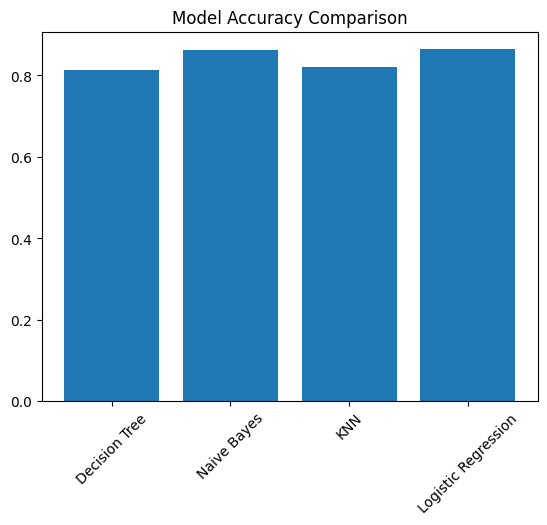

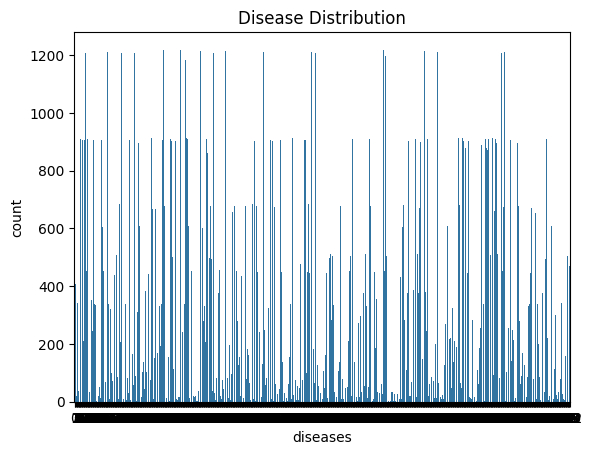

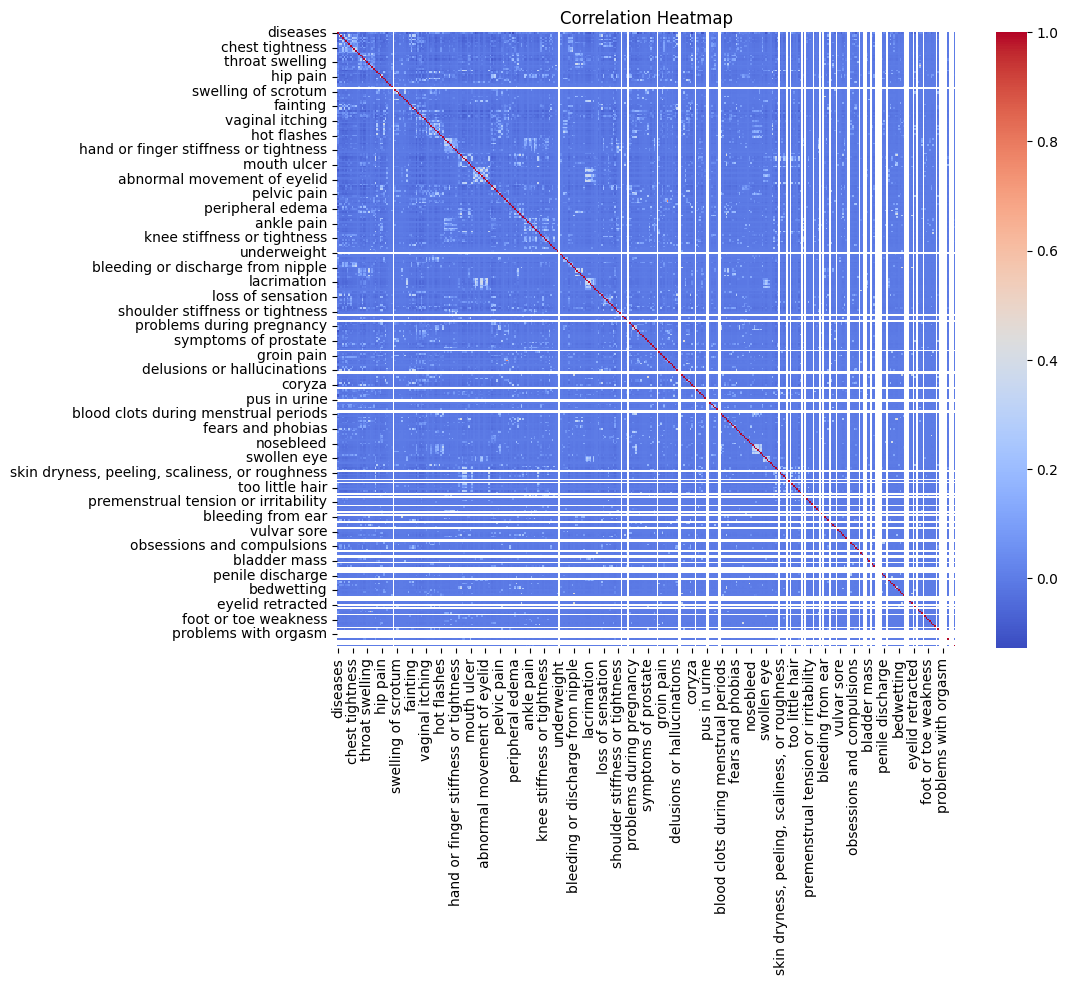

In [ ]:
# =========================
# Step 5 - Visualization
# =========================

# Accuracy Bar Graph
plt.figure()
plt.bar(models.keys(), accuracy_list)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

# Disease Distribution
plt.figure()
sns.countplot(x=data['diseases'])
plt.title("Disease Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# =========================
# Step 6 - User Input Symptoms
# =========================
symptom_columns = X.columns.tolist()

# print("\nAvailable Symptoms:")
# for s in symptom_columns:
    # print("-", s)

user_input = input("\nEnter symptoms separated by comma: ")

input_symptoms = [s.strip().lower() for s in user_input.split(",")]

# Create input vector
input_vector = [0] * len(symptom_columns)
matched_symptoms = []
for symptom in input_symptoms:
    match = get_close_matches(symptom, symptom_columns, n=1, cutoff=0.6)
    if match:
        index = symptom_columns.index(match[0])
        input_vector[index] = 1
        matched_symptoms.append(match[0])

print("\nMatched Symptoms:", matched_symptoms)

# # =========================
# # Step 7 - Predict Disease
# # =========================
# input_df = pd.DataFrame([input_vector], columns=symptom_columns)

# # Get probabilities
# probs = best_model.predict_proba(input_df)[0]

# # Top 3 diseases
# top_indices = np.argsort(probs)[-3:][::-1]

# print("\nTop Possible Diseases:")

# for i in top_indices:
#     disease_name = le.inverse_transform([i])[0]
#     probability = probs[i]
#     print(disease_name, "--> Probability:", round(probability, 2))

# =========================
# Step 7 - Predict Disease
# =========================
input_df = pd.DataFrame([input_vector], columns=symptom_columns)

# Get probabilities
probs = best_model.predict_proba(input_df)[0]

# Get index of highest probability
best_index = np.argmax(probs)

# Get disease name
predicted_disease = le.inverse_transform([best_index])[0]

print("\nPredicted Disease:", predicted_disease)


Enter symptoms separated by comma: high fever, abdominal pain, weakness, fatigue, headache, weight loss, dry cough, rash

Matched Symptoms: ['fever', 'upper abdominal pain', 'weakness', 'fatigue', 'headache', 'recent weight loss', 'cough', 'skin rash']

Predicted Disease: molluscum contagiosum
